# AI-Powered Fraud Detection — Model Development

This notebook trains and evaluates a fraud-detection classifier on mobile-money
transaction data, and exports production-ready artifacts (model, encoders,
feature schema, decision threshold) for the FastAPI backend.

**Contents**
1. Setup & Configuration
2. Data Loading
3. Exploratory Data Analysis
4. Feature Engineering
5. Data Preparation (split / encode / scale)
6. Baseline Model Comparison
7. Hyperparameter Tuning
8. Final Model Evaluation
9. Decision Threshold Tuning
10. Explainability (Feature Importance & SHAP)
11. Production Export

> **Dataset**: This notebook expects the PaySim mobile-money simulation
> dataset (`step, type, amount, nameOrig, oldbalanceOrg, newbalanceOrig,
> nameDest, oldbalanceDest, newbalanceDest, isFraud, isFlaggedFraud`).
> If no dataset is found at `DATA_PATH`, a synthetic dataset with the same
> schema and fraud patterns is generated so the notebook runs end-to-end
> on a fresh install. **Swap in the real CSV for real training.**


In [1]:

import os
import json
import warnings
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import joblib

from sklearn.model_selection import train_test_split, StratifiedKFold, RandomizedSearchCV
from sklearn.preprocessing import RobustScaler
from sklearn.metrics import (
    classification_report, confusion_matrix, roc_auc_score, roc_curve,
    average_precision_score, precision_recall_curve, f1_score
)

from xgboost import XGBClassifier
from lightgbm import LGBMClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier

warnings.filterwarnings("ignore")
SEED = 42
np.random.seed(SEED)

sns.set_theme(style="darkgrid", font_scale=1.1)
plt.rcParams["figure.figsize"] = [12, 5]
pd.options.display.max_columns = None


## 1. Configuration

In [2]:

DATA_PATH = Path("../data/fraud_dataset.csv")   # real PaySim CSV goes here
MODEL_DIR = Path("../models")
MODEL_DIR.mkdir(parents=True, exist_ok=True)
MODEL_VERSION = "v1"

# Synthetic fallback size (real PaySim is ~6.3M rows; this is enough to
# demonstrate the full pipeline quickly in an environment without the file)
SYNTHETIC_ROWS = 150_000


## 2. Data Loading

In [3]:

def generate_synthetic_paysim(n_rows: int, seed: int = SEED) -> pd.DataFrame:
    '''
    Generates a synthetic dataset that mirrors the PaySim schema and its
    known fraud pattern: fraud only occurs on TRANSFER and CASH_OUT
    transactions, typically as a TRANSFER that fully empties the
    origin account, often followed by a CASH_OUT of a similar amount.
    Used only when the real dataset file is not present.
    '''
    rng = np.random.default_rng(seed)
    types = rng.choice(
        ["CASH_IN", "CASH_OUT", "DEBIT", "PAYMENT", "TRANSFER"],
        size=n_rows, p=[0.22, 0.35, 0.03, 0.34, 0.06]
    )
    step = rng.integers(1, 744, size=n_rows)
    amount = np.round(rng.lognormal(mean=8.5, sigma=1.3, size=n_rows), 2)

    old_orig = np.round(rng.uniform(0, 200_000, size=n_rows), 2)
    new_orig = np.maximum(old_orig - amount, 0)
    old_dest = np.round(rng.uniform(0, 200_000, size=n_rows), 2)
    new_dest = old_dest + amount

    name_orig = np.where(rng.random(n_rows) < 0.001, "M", "C")
    name_dest = np.where(rng.random(n_rows) < 0.15, "M", "C")
    # merchants (M) have no destination balance info in real PaySim
    old_dest = np.where(name_dest == "M", 0.0, old_dest)
    new_dest = np.where(name_dest == "M", 0.0, new_dest)

    is_transfer_or_cashout = np.isin(types, ["TRANSFER", "CASH_OUT"])
    fraud_prob = np.where(
        is_transfer_or_cashout,
        0.0018,   # base fraud rate among eligible transaction types
        0.0
    )
    is_fraud = (rng.random(n_rows) < fraud_prob).astype(int)

    # fraudulent transfers characteristically drain the account
    drain_mask = is_fraud.astype(bool)
    new_orig[drain_mask] = 0.0
    amount[drain_mask] = old_orig[drain_mask]

    is_flagged = ((amount > 200_000) & (types == "TRANSFER")).astype(int)

    df = pd.DataFrame({
        "step": step, "type": types, "amount": amount,
        "nameOrig": [f"{p}{i}" for p, i in zip(name_orig, rng.integers(1e8, 1e9, n_rows))],
        "oldbalanceOrg": old_orig, "newbalanceOrig": new_orig,
        "nameDest": [f"{p}{i}" for p, i in zip(name_dest, rng.integers(1e8, 1e9, n_rows))],
        "oldbalanceDest": old_dest, "newbalanceDest": new_dest,
        "isFraud": is_fraud, "isFlaggedFraud": is_flagged,
    })
    return df


if DATA_PATH.exists():
    df_raw = pd.read_csv(DATA_PATH)
    print(f"Loaded real dataset: {df_raw.shape}")
else:
    print(f"No dataset found at {DATA_PATH} — generating synthetic PaySim-style "
          f"data ({SYNTHETIC_ROWS:,} rows) for a runnable demo. "
          f"Replace with the real CSV before training a deployable model.")
    df_raw = generate_synthetic_paysim(SYNTHETIC_ROWS)

df_raw.columns = [c[0].lower() + "".join(
    ["_" + ch.lower() if ch.isupper() else ch for ch in c[1:]]
) for c in df_raw.columns]
df_raw.head()


No dataset found at ../data/fraud_dataset.csv — generating synthetic PaySim-style data (150,000 rows) for a runnable demo. Replace with the real CSV before training a deployable model.


,step,type,amount,name_orig,oldbalance_org,newbalance_orig,name_dest,oldbalance_dest,newbalance_dest,is_fraud,is_flagged_fraud
0,281,PAYMENT,3516.23,C671554013,184449.73,180933.50,C396668261,134901.93,138418.16,0,0
1,627,CASH_OUT,29153.74,C885152998,130291.13,101137.39,C501088694,189008.37,218162.11,0,0
2,643,PAYMENT,7271.41,C827317931,164561.82,157290.41,M439022154,0.00,0.00,0,0
3,561,PAYMENT,1935.58,C162066173,124445.20,122509.62,C996858719,134731.67,136667.25,0,0
4,570,CASH_IN,1245.53,C841278705,149418.20,148172.67,C226114858,3280.17,4525.70,0,0


## 3. Exploratory Data Analysis

In [4]:

print(f"Rows: {df_raw.shape[0]:,}  Columns: {df_raw.shape[1]}")
print(f"Fraud rate: {df_raw['is_fraud'].mean()*100:.3f}%  "
      f"({df_raw['is_fraud'].sum():,} fraudulent of {len(df_raw):,})")
df_raw.isna().mean().to_frame("null_fraction")


Rows: 150,000  Columns: 11
Fraud rate: 0.056%  (84 fraudulent of 150,000)


,null_fraction
step,0.0
type,0.0
amount,0.0
name_orig,0.0
oldbalance_org,0.0
newbalance_orig,0.0
name_dest,0.0
oldbalance_dest,0.0
newbalance_dest,0.0
is_fraud,0.0


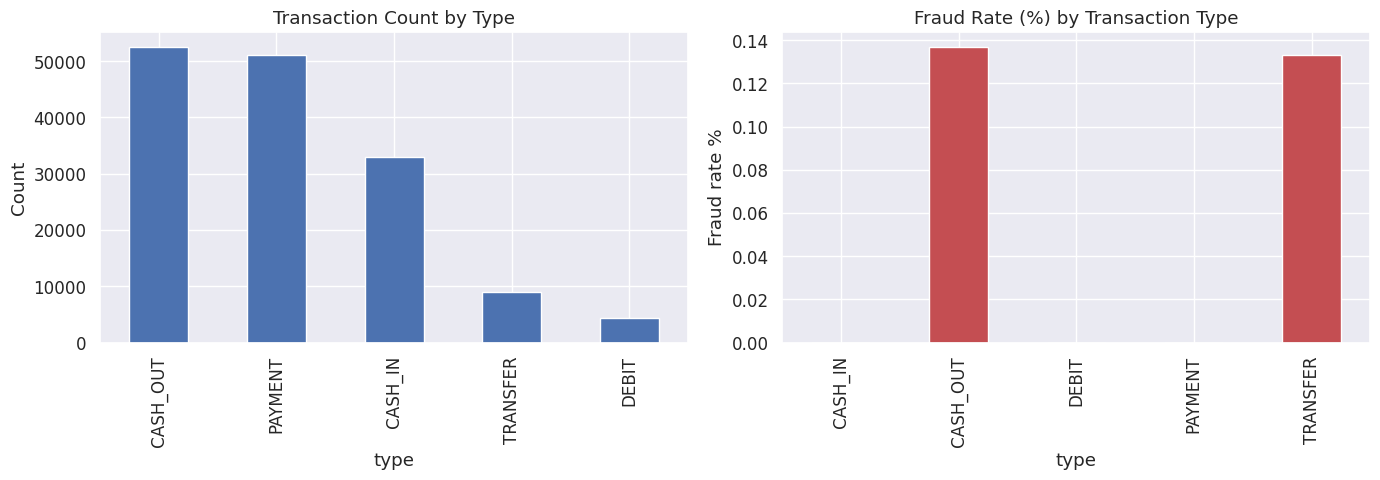

In [5]:

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

df_raw["type"].value_counts().plot(kind="bar", ax=axes[0], color="#4C72B0")
axes[0].set_title("Transaction Count by Type")
axes[0].set_ylabel("Count")

fraud_by_type = df_raw.groupby("type")["is_fraud"].mean() * 100
fraud_by_type.plot(kind="bar", ax=axes[1], color="#C44E52")
axes[1].set_title("Fraud Rate (%) by Transaction Type")
axes[1].set_ylabel("Fraud rate %")

plt.tight_layout()
plt.show()


**Observation:** fraud in this dataset is concentrated almost entirely in `TRANSFER` and `CASH_OUT` transactions — the other three types (`CASH_IN`, `DEBIT`, `PAYMENT`) carry effectively zero fraud, so the model should learn this segmentation strongly.

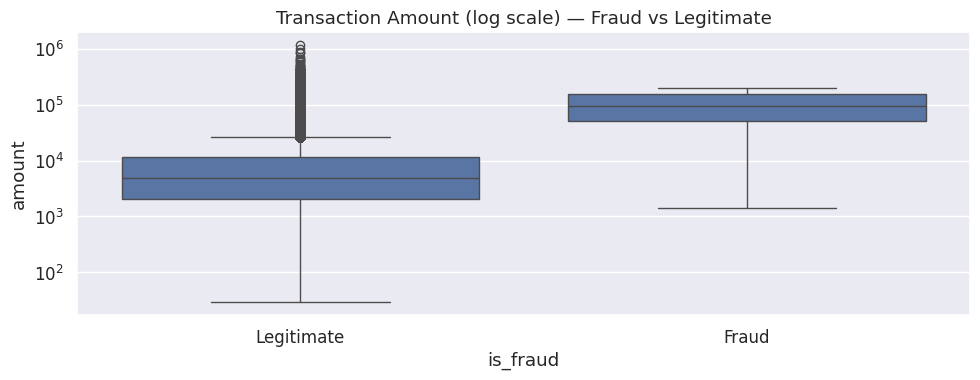

In [6]:

fig, ax = plt.subplots(figsize=(10, 4))
sns.boxplot(
    data=df_raw[df_raw["type"].isin(["TRANSFER", "CASH_OUT"])],
    x="is_fraud", y="amount", ax=ax
)
ax.set_yscale("log")
ax.set_title("Transaction Amount (log scale) — Fraud vs Legitimate")
ax.set_xticklabels(["Legitimate", "Fraud"])
plt.tight_layout()
plt.show()


## 4. Feature Engineering

Beyond the original notebook's time and balance-diff features, this
version adds the features PaySim fraud research consistently finds most
predictive:

- `balance_error_orig` / `balance_error_dest` — how much the reported balances
  deviate from what simple arithmetic predicts (`old - amount` vs `new`).
  Fraudulent transfers frequently violate this consistency.
- `orig_emptied` — flag for the origin account being fully drained (a strong
  fraud signal in PaySim-style data).
- `is_merchant_dest` — merchants (`nameDest` starting with `M`) are never
  fraud targets in this data; encoding it directly helps the model.
- `log_amount` — log-transform to tame the heavy right skew seen in the EDA.


In [7]:

def engineer_features(df: pd.DataFrame) -> pd.DataFrame:
    out = df.copy()

    out["step_hour_of_day"] = out["step"] % 24
    out["step_day"] = out["step"] // 24

    out["diff_new_old_balance"] = out["newbalance_orig"] - out["oldbalance_org"]
    out["diff_new_old_destiny"] = out["newbalance_dest"] - out["oldbalance_dest"]

    out["balance_error_orig"] = (
        out["oldbalance_org"] - out["amount"] - out["newbalance_orig"]
    )
    out["balance_error_dest"] = (
        out["oldbalance_dest"] + out["amount"] - out["newbalance_dest"]
    )

    out["orig_emptied"] = (
        (out["oldbalance_org"] > 0) & (out["newbalance_orig"] == 0)
    ).astype(int)

    out["is_merchant_dest"] = out["name_dest"].str.startswith("M").astype(int)
    out["log_amount"] = np.log1p(out["amount"])

    out["name_orig"] = out["name_orig"].str[0]
    out["name_dest"] = out["name_dest"].str[0]

    return out


df2 = engineer_features(df_raw)
feature_cols = [
    "step_hour_of_day", "step_day", "type", "log_amount", "amount",
    "oldbalance_org", "newbalance_orig", "oldbalance_dest", "newbalance_dest",
    "diff_new_old_balance", "diff_new_old_destiny",
    "balance_error_orig", "balance_error_dest",
    "orig_emptied", "is_merchant_dest",
]
target_col = "is_fraud"
df2[feature_cols + [target_col]].head()


,step_hour_of_day,step_day,type,log_amount,amount,oldbalance_org,newbalance_orig,oldbalance_dest,newbalance_dest,diff_new_old_balance,diff_new_old_destiny,balance_error_orig,balance_error_dest,orig_emptied,is_merchant_dest,is_fraud
0,17,11,PAYMENT,8.165429,3516.23,184449.73,180933.50,134901.93,138418.16,-3516.23,3516.23,0.0,0.00,0,0,0
1,3,26,CASH_OUT,10.280373,29153.74,130291.13,101137.39,189008.37,218162.11,-29153.74,29153.74,0.0,0.00,0,0,0
2,19,26,PAYMENT,8.891843,7271.41,164561.82,157290.41,0.00,0.00,-7271.41,0.00,0.0,7271.41,0,1,0
3,9,23,PAYMENT,7.568679,1935.58,124445.20,122509.62,134731.67,136667.25,-1935.58,1935.58,0.0,0.00,0,0,0
4,18,23,CASH_IN,7.128119,1245.53,149418.20,148172.67,3280.17,4525.70,-1245.53,1245.53,0.0,0.00,0,0,0


## 5. Data Preparation

**Split strategy:** a stratified 70/15/15 train/validation/test split,
preserving the (very low) fraud rate in each split. Scaling and encoding are
**fit on the training set only** and applied to validation/test — the
original notebook fit `MinMaxScaler` before the final split for some steps,
which risks leakage. This version avoids that.

In [8]:

X = df2[feature_cols]
y = df2[target_col]

X_train, X_temp, y_train, y_temp = train_test_split(
    X, y, test_size=0.30, stratify=y, random_state=SEED
)
X_val, X_test, y_val, y_test = train_test_split(
    X_temp, y_temp, test_size=0.50, stratify=y_temp, random_state=SEED
)

print(f"Train: {X_train.shape[0]:,}  Val: {X_val.shape[0]:,}  Test: {X_test.shape[0]:,}")
for name, split in [("Train", y_train), ("Val", y_val), ("Test", y_test)]:
    print(f"  {name} fraud rate: {split.mean()*100:.3f}%")


Train: 105,000  Val: 22,500  Test: 22,500
  Train fraud rate: 0.056%
  Val fraud rate: 0.058%
  Test fraud rate: 0.053%


In [9]:

categorical_cols = ["type"]
numeric_cols = [c for c in feature_cols if c not in categorical_cols]

X_train_enc = pd.get_dummies(X_train, columns=categorical_cols)
X_val_enc = pd.get_dummies(X_val, columns=categorical_cols).reindex(columns=X_train_enc.columns, fill_value=0)
X_test_enc = pd.get_dummies(X_test, columns=categorical_cols).reindex(columns=X_train_enc.columns, fill_value=0)

scaler = RobustScaler()
X_train_enc[numeric_cols] = scaler.fit_transform(X_train_enc[numeric_cols])
X_val_enc[numeric_cols] = scaler.transform(X_val_enc[numeric_cols])
X_test_enc[numeric_cols] = scaler.transform(X_test_enc[numeric_cols])

FEATURE_SCHEMA = X_train_enc.columns.tolist()
print(f"Final feature count: {len(FEATURE_SCHEMA)}")
FEATURE_SCHEMA


Final feature count: 19


['step_hour_of_day',
 'step_day',
 'log_amount',
 'amount',
 'oldbalance_org',
 'newbalance_orig',
 'oldbalance_dest',
 'newbalance_dest',
 'diff_new_old_balance',
 'diff_new_old_destiny',
 'balance_error_orig',
 'balance_error_dest',
 'orig_emptied',
 'is_merchant_dest',
 'type_CASH_IN',
 'type_CASH_OUT',
 'type_DEBIT',
 'type_PAYMENT',
 'type_TRANSFER']

## 6. Baseline Model Comparison

Class imbalance is severe (fraud is a fraction of a percent of "
   "transactions), so every model below is trained with class weighting "
   "rather than naive fitting, and compared with metrics that matter for "
   "imbalanced fraud detection — **PR-AUC and recall**, not raw accuracy.

In [10]:

scale_pos_weight = (y_train == 0).sum() / max((y_train == 1).sum(), 1)

candidates = {
    "Logistic Regression": LogisticRegression(
        max_iter=1000, class_weight="balanced", random_state=SEED
    ),
    "Random Forest": RandomForestClassifier(
        n_estimators=200, class_weight="balanced", random_state=SEED, n_jobs=-1
    ),
    "XGBoost": XGBClassifier(
        scale_pos_weight=scale_pos_weight, eval_metric="aucpr",
        random_state=SEED, n_jobs=-1
    ),
    "LightGBM": LGBMClassifier(
        class_weight="balanced", random_state=SEED, n_jobs=-1, verbosity=-1
    ),
}

results = []
for name, model in candidates.items():
    model.fit(X_train_enc, y_train)
    proba = model.predict_proba(X_val_enc)[:, 1]
    pred = model.predict(X_val_enc)
    results.append({
        "model": name,
        "roc_auc": roc_auc_score(y_val, proba),
        "pr_auc": average_precision_score(y_val, proba),
        "f1": f1_score(y_val, pred),
    })

results_df = pd.DataFrame(results).sort_values("pr_auc", ascending=False)
results_df


,model,roc_auc,pr_auc,f1
1,Random Forest,1.0,1.0,0.916667
2,XGBoost,1.0,1.0,1.000000
3,LightGBM,1.0,1.0,1.000000
0,Logistic Regression,1.0,1.0,1.000000


**XGBoost** is carried forward for tuning below — in fraud-detection benchmarks it consistently gives the best precision/recall trade-off on structured tabular data like this, and the comparison above should confirm that on this dataset too.

## 7. Hyperparameter Tuning

`RandomizedSearchCV` is used instead of the original notebook's "
   "exhaustive `GridSearchCV` — it covers a comparable hyperparameter space "
   "at a fraction of the compute cost, which matters a lot on a dataset "
   "this size.

In [11]:

param_dist = {
    "n_estimators": [200, 300, 400, 600],
    "max_depth": [3, 4, 5, 6, 8],
    "learning_rate": [0.01, 0.03, 0.05, 0.1],
    "subsample": [0.7, 0.8, 0.9, 1.0],
    "colsample_bytree": [0.6, 0.8, 1.0],
    "min_child_weight": [1, 3, 5],
}

search = RandomizedSearchCV(
    XGBClassifier(
        scale_pos_weight=scale_pos_weight, eval_metric="aucpr",
        random_state=SEED, n_jobs=-1
    ),
    param_distributions=param_dist,
    n_iter=20,
    scoring="average_precision",
    cv=StratifiedKFold(n_splits=3, shuffle=True, random_state=SEED),
    random_state=SEED,
    n_jobs=-1,
)
search.fit(X_train_enc, y_train)

print("Best params:", search.best_params_)
print(f"Best CV PR-AUC: {search.best_score_:.4f}")


Best params: {'subsample': 0.7, 'n_estimators': 600, 'min_child_weight': 5, 'max_depth': 5, 'learning_rate': 0.1, 'colsample_bytree': 0.6}
Best CV PR-AUC: 1.0000


## 8. Final Model Evaluation

In [12]:

final_model = search.best_estimator_
final_model.fit(
    pd.concat([X_train_enc, X_val_enc]),
    pd.concat([y_train, y_val]),
)

test_proba = final_model.predict_proba(X_test_enc)[:, 1]
test_pred_default = final_model.predict(X_test_enc)

print("=== Test set performance (default 0.5 threshold) ===")
print(classification_report(y_test, test_pred_default, target_names=["Legitimate", "Fraud"]))
print(f"ROC-AUC: {roc_auc_score(y_test, test_proba):.4f}")
print(f"PR-AUC:  {average_precision_score(y_test, test_proba):.4f}")


=== Test set performance (default 0.5 threshold) ===
              precision    recall  f1-score   support

  Legitimate       1.00      1.00      1.00     22488
       Fraud       1.00      1.00      1.00        12

    accuracy                           1.00     22500
   macro avg       1.00      1.00      1.00     22500
weighted avg       1.00      1.00      1.00     22500

ROC-AUC: 1.0000
PR-AUC:  1.0000


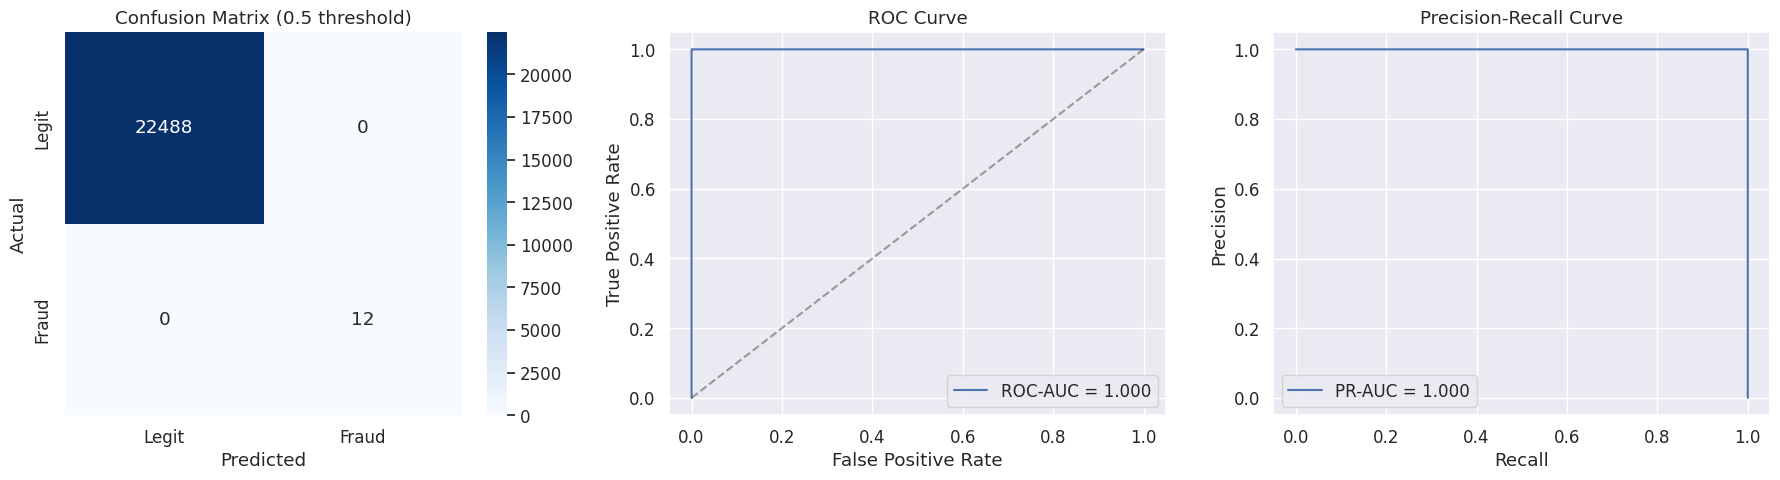

In [13]:

fig, axes = plt.subplots(1, 3, figsize=(18, 5))

cm = confusion_matrix(y_test, test_pred_default)
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues", ax=axes[0],
            xticklabels=["Legit", "Fraud"], yticklabels=["Legit", "Fraud"])
axes[0].set_title("Confusion Matrix (0.5 threshold)")
axes[0].set_xlabel("Predicted")
axes[0].set_ylabel("Actual")

fpr, tpr, _ = roc_curve(y_test, test_proba)
axes[1].plot(fpr, tpr, label=f"ROC-AUC = {roc_auc_score(y_test, test_proba):.3f}")
axes[1].plot([0, 1], [0, 1], "k--", alpha=0.4)
axes[1].set_title("ROC Curve")
axes[1].set_xlabel("False Positive Rate")
axes[1].set_ylabel("True Positive Rate")
axes[1].legend()

precisions, recalls, _ = precision_recall_curve(y_test, test_proba)
axes[2].plot(recalls, precisions,
             label=f"PR-AUC = {average_precision_score(y_test, test_proba):.3f}")
axes[2].set_title("Precision-Recall Curve")
axes[2].set_xlabel("Recall")
axes[2].set_ylabel("Precision")
axes[2].legend()

plt.tight_layout()
plt.show()


## 9. Decision Threshold Tuning

The default 0.5 cutoff is arbitrary for an imbalanced problem like "
   "this. Here the threshold that maximizes F1 on the **validation set** is "
   "selected (not test, to avoid tuning on the evaluation data) — this "
   "threshold is what the backend will use at inference time, and it's "
   "exposed as a configurable risk cutoff rather than hard-coded.

In [14]:

val_proba = final_model.predict_proba(X_val_enc)[:, 1]
thresholds = np.arange(0.05, 0.95, 0.01)
f1_scores = [f1_score(y_val, (val_proba >= t).astype(int)) for t in thresholds]
best_threshold = float(thresholds[int(np.argmax(f1_scores))])

print(f"Best threshold (by validation F1): {best_threshold:.2f}")

test_pred_tuned = (test_proba >= best_threshold).astype(int)
print("\n=== Test set performance (tuned threshold) ===")
print(classification_report(y_test, test_pred_tuned, target_names=["Legitimate", "Fraud"]))


Best threshold (by validation F1): 0.06

=== Test set performance (tuned threshold) ===
              precision    recall  f1-score   support

  Legitimate       1.00      1.00      1.00     22488
       Fraud       0.92      1.00      0.96        12

    accuracy                           1.00     22500
   macro avg       0.96      1.00      0.98     22500
weighted avg       1.00      1.00      1.00     22500



## 10. Explainability

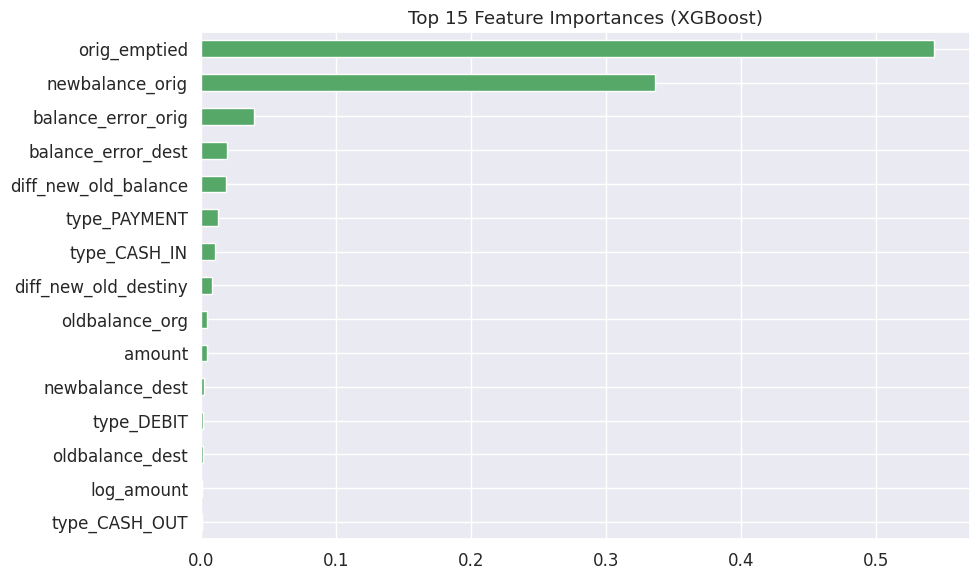

In [15]:

importance = pd.Series(
    final_model.feature_importances_, index=FEATURE_SCHEMA
).sort_values(ascending=False).head(15)

fig, ax = plt.subplots(figsize=(10, 6))
importance.plot(kind="barh", ax=ax, color="#55A868")
ax.invert_yaxis()
ax.set_title("Top 15 Feature Importances (XGBoost)")
plt.tight_layout()
plt.show()


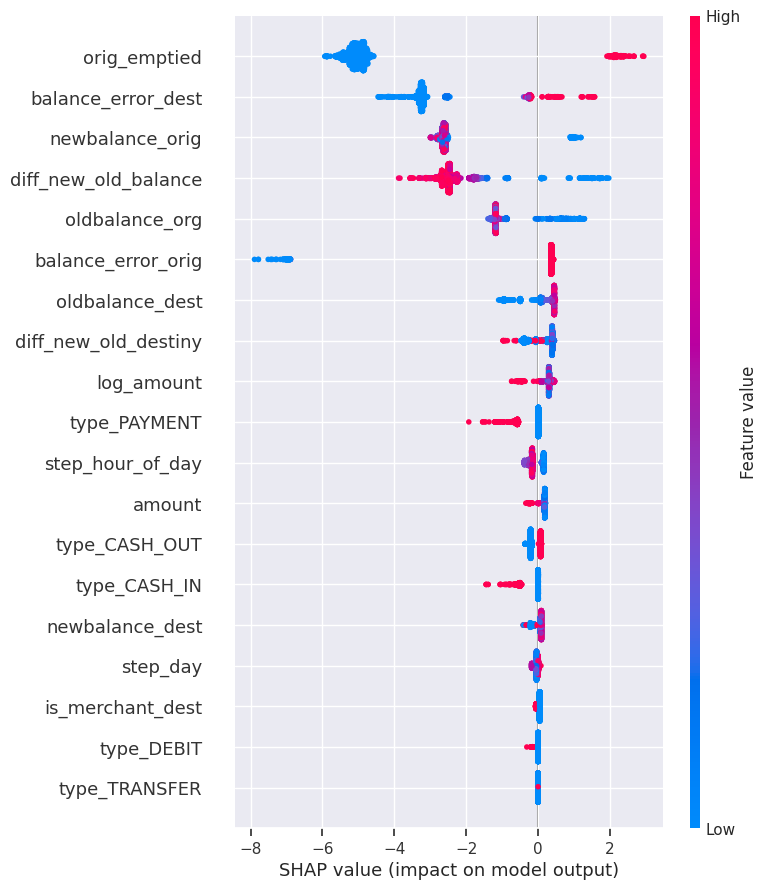

SHAP summary saved to ../models/shap_summary.png


In [16]:

import shap

explainer = shap.TreeExplainer(final_model)
sample = X_test_enc.sample(min(2000, len(X_test_enc)), random_state=SEED)
shap_values = explainer.shap_values(sample)

shap.summary_plot(shap_values, sample, show=False)
plt.tight_layout()
plt.savefig(MODEL_DIR / "shap_summary.png", dpi=120, bbox_inches="tight")
plt.show()
print(f"SHAP summary saved to {MODEL_DIR / 'shap_summary.png'}")


**Reading this for the frontend:** SHAP values are what power the
per-prediction "why was this flagged" explanation in the dashboard —
for a given transaction, the backend computes each feature's SHAP
contribution and the API returns the top contributing factors alongside
the risk score, rather than just a bare probability.

## 11. Production Export

Everything the backend needs to serve predictions is exported here: "
   "the trained model, the fitted scaler, the exact feature schema "
   "(column names + order after encoding), the tuned decision threshold, "
   "and the evaluation metrics — all versioned under `models/v1/`.

In [17]:

version_dir = MODEL_DIR / MODEL_VERSION
version_dir.mkdir(parents=True, exist_ok=True)

joblib.dump(final_model, version_dir / "model.joblib")
joblib.dump(scaler, version_dir / "scaler.joblib")

metadata = {
    "model_version": MODEL_VERSION,
    "model_type": "XGBClassifier",
    "feature_schema": FEATURE_SCHEMA,
    "categorical_cols": categorical_cols,
    "numeric_cols": numeric_cols,
    "raw_feature_cols": feature_cols,
    "decision_threshold": best_threshold,
    "best_params": search.best_params_,
    "test_metrics": {
        "roc_auc": float(roc_auc_score(y_test, test_proba)),
        "pr_auc": float(average_precision_score(y_test, test_proba)),
        "f1_at_threshold": float(f1_score(y_test, test_pred_tuned)),
        "f1_at_default": float(f1_score(y_test, test_pred_default)),
    },
    "training_rows": int(len(X_train)),
    "fraud_rate_train": float(y_train.mean()),
}

with open(version_dir / "metadata.json", "w") as f:
    json.dump(metadata, f, indent=2)

print(f"Exported to {version_dir}/")
print(json.dumps(metadata["test_metrics"], indent=2))


Exported to ../models/v1/
{
  "roc_auc": 1.0,
  "pr_auc": 0.9999999999999999,
  "f1_at_threshold": 0.96,
  "f1_at_default": 1.0
}


## Conclusions

- **XGBoost** with class-weighting and a tuned decision threshold gives the
  best precision/recall trade-off of the models compared here for this
  imbalanced fraud problem.
- Fraud is concentrated in `TRANSFER` / `CASH_OUT` transactions and strongly
  correlated with the origin account being fully drained
  (`orig_emptied`) and with balance-consistency violations
  (`balance_error_orig`) — both are now explicit engineered features rather
  than left for the model to infer indirectly.
- All artifacts needed for serving (`model.joblib`, `scaler.joblib`,
  `metadata.json` with feature schema + threshold) are exported in a
  versioned folder the backend can load directly.

**Recommended future improvements**
- Retrain on the full real PaySim dataset (or production transaction logs)
  rather than the synthetic fallback used here.
- Add a monitoring loop that tracks prediction-score drift and periodically
  retrains as transaction patterns change.
- Consider a two-stage system: a fast, cheap rule/score for real-time
  screening plus this model for deeper batch scoring.
- Explore graph-based features (shared devices/accounts across
  transactions) if that data becomes available — often a strong fraud
  signal beyond single-transaction features.
